#**LOAN STATUS PREDICATION**




Import required libraries

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.model_selection import train_test_split

Data Collection and Preparation

In [139]:
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [141]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [142]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [143]:
# drop null values of the column 'Credit History'
df.dropna(inplace = True)

#Visualisation

In [144]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


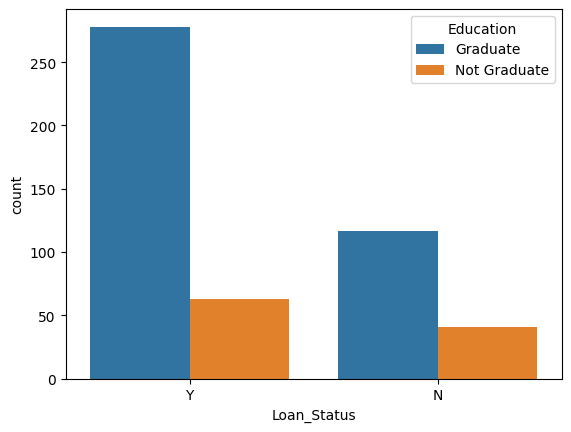

In [145]:
# Loan_Status and Education
sns.countplot(data = df, x = 'Loan_Status', hue = 'Education')
plt.show()

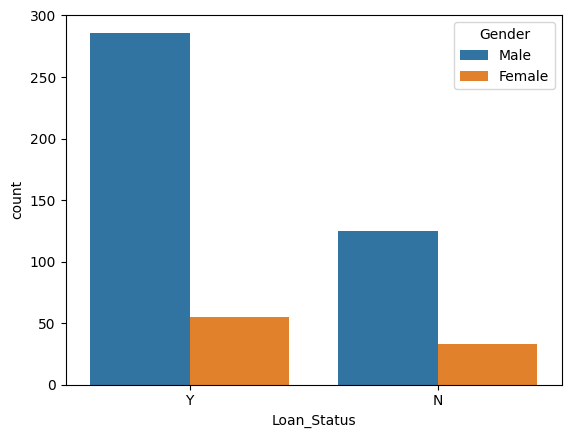

In [146]:
# Loan_Status and Gender
sns.countplot(data = df, x = 'Loan_Status', hue = 'Gender')
plt.show()

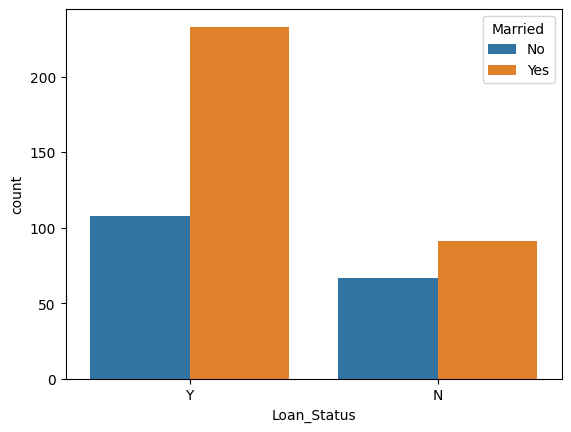

In [147]:
# Loan_Status and Married
sns.countplot(data = df, x = 'Loan_Status', hue = 'Married')
plt.show()

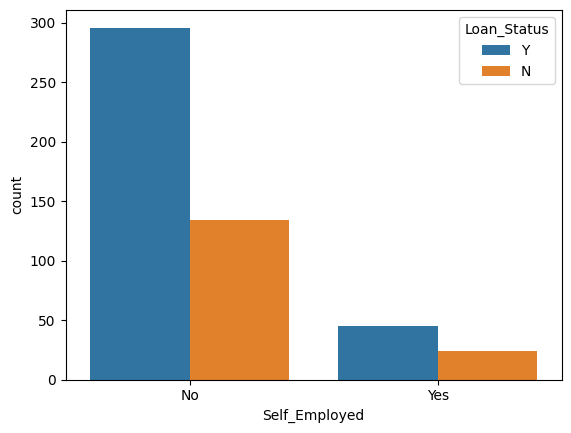

In [148]:
# Loan_Status and Self_Employed
sns.countplot(data = df, hue = 'Loan_Status', x = 'Self_Employed')
plt.show()

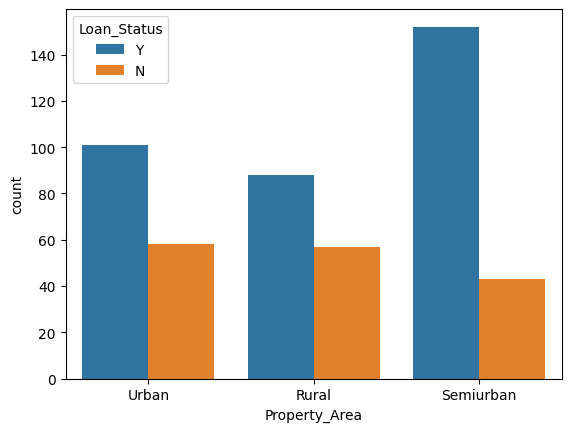

In [149]:
# Loan_Status and Area Type
sns.countplot(data = df, x = 'Property_Area', hue = 'Loan_Status')
plt.show()

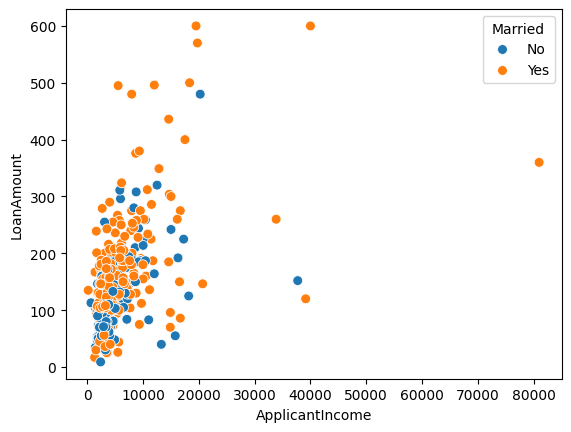

In [150]:
# ApplicantIncome and LoanAmount
sns.scatterplot(data = df, x = 'ApplicantIncome', y = 'LoanAmount', hue = 'Married', s = 50)
plt.show()

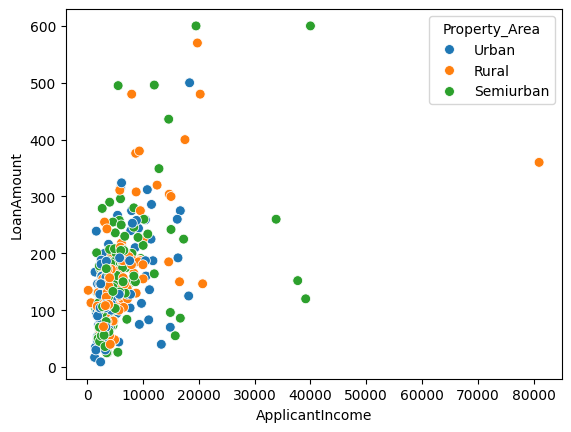

In [151]:
sns.scatterplot(data = df, x = 'ApplicantIncome', y = 'LoanAmount', hue = 'Property_Area', s = 50)
plt.show()

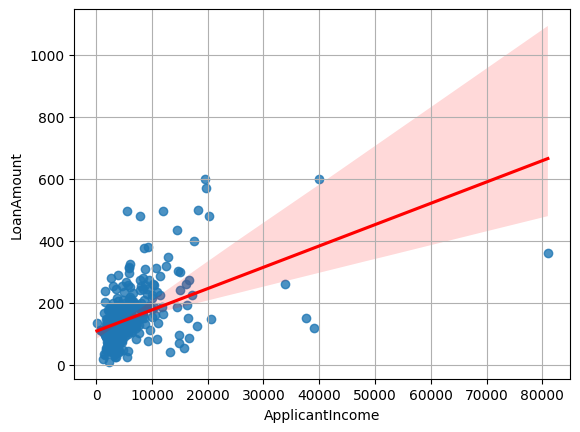

In [152]:
sns.regplot(data = df, x = 'ApplicantIncome', y = 'LoanAmount', line_kws={'color':'red'})
plt.grid()
plt.show()

Train and Test Split

In [153]:
X = df.drop('Loan_ID', axis = 1)
train_set, test_set = train_test_split(X, test_size = 0.2, random_state=42)
train_set

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
67,Male,Yes,1,Graduate,No,10750,0.000000,312.0,360.0,1.0,Urban,Y
277,Male,Yes,0,Graduate,No,3103,1300.000000,80.0,360.0,1.0,Urban,Y
347,Male,Yes,2,Not Graduate,No,3083,2168.000000,126.0,360.0,1.0,Urban,Y
599,Male,Yes,2,Graduate,No,5780,0.000000,192.0,360.0,1.0,Urban,Y
270,Female,No,0,Graduate,No,3237,0.000000,30.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
134,Male,No,0,Graduate,No,4895,0.000000,102.0,360.0,1.0,Semiurban,Y
330,Male,No,1,Graduate,No,4384,1793.000000,117.0,360.0,1.0,Urban,Y
428,Male,Yes,0,Graduate,No,2920,16.120001,87.0,360.0,1.0,Rural,Y
537,Male,No,2,Graduate,No,3617,0.000000,107.0,360.0,1.0,Semiurban,Y


Working with string columns

In [154]:
y = train_set['Loan_Status']

In [155]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
loan = train_set.drop('Loan_Status', axis = 1)
loan_num = loan.select_dtypes(include=['int64', 'float64']).columns
loan_str = loan.drop(loan_num, axis = 1).columns

full_pipeline = ColumnTransformer([
    ('num', StandardScaler(), loan_num),
    ('cat', OneHotEncoder(), loan_str)
])

df_final = full_pipeline.fit_transform(loan)

In [156]:
df_final[:3]

array([[ 1.23457572, -0.58014445,  2.07600751,  0.26502329,  0.38282075,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ],
       [-0.47434941, -0.09728739, -0.81657643,  0.26502329,  0.38282075,
         0.        ,  1.        ,  0.        ,  1.        ,  1.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ],
       [-0.47881894,  0.22511256, -0.24304686,  0.26502329,  0.38282075,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  1.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ]])

Traing the model:
Support Vector Machine Model

In [157]:
from sklearn import svm

classifier = svm.SVC(kernel='linear')

classifier.fit(df_final, y)


SVC(kernel='linear')

In [158]:
test_data = loan.sample(15)
test_labels = train_set.loc[test_data.index]['Loan_Status']

test_prepared = full_pipeline.transform(test_data)

prediction = classifier.predict(test_prepared)
pd.DataFrame({'Predict':prediction, 'Real':test_labels})

,Predict,Real
148,Y,N
110,Y,Y
479,Y,N
557,Y,Y
461,Y,Y
128,N,N
208,Y,Y
3,Y,Y
549,Y,Y
573,Y,N


Test the model

In [159]:
test_ml = test_set.drop('Loan_Status', axis =1)

In [160]:
y_test = test_set['Loan_Status']

In [161]:
test_set_prepared = full_pipeline.transform(test_ml)
test_set_prepared

array([[-0.4229498 , -0.58014445, -0.94125677, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.74650295, -0.58014445,  0.80426802, ...,  0.        ,
         0.        ,  1.        ],
       [-0.65357759, -0.21399023, -0.8415125 , ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.58675811,  0.12965543, -0.3677272 , ...,  0.        ,
         1.        ,  0.        ],
       [-0.29579165,  0.03865545, -0.45500344, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.68705819, -0.58014445,  0.08112203, ...,  0.        ,
         1.        ,  0.        ]])

In [162]:
test_prediction = classifier.predict(test_set_prepared)

accur_score = accuracy_score(y_test, test_prediction)
print("Accuracy Percentage:", int(accur_score*100), '%')

Accuracy Percentage: 83 %


Save the model by using joblib

In [163]:
import joblib
filename = 'SVM_model.jbl'
joblib.dump(classifier, filename)

['SVM_model.jbl']